In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange


import matplotlib as mpl
import os
import sys
import math
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. concatenated records

#### 1.1 records before GDPR

In [3]:
df_pre = pd.read_csv("pregdprApril2016_STM.csv")
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,910559805.0,8.516,10.0,1.0,1.421215,910559805.0,8.569,10.0,1.0,1.421215,...,8.520,10.0,1.0,1.421215,910559805.0,8.667,10.0,1.0,1.421215,8.576036
1,910559805.0,8.569,10.0,1.0,1.421215,910559805.0,8.398,10.0,1.0,1.421215,...,8.667,10.0,1.0,1.421215,910559805.0,8.883,10.0,1.0,1.421215,8.465118
2,910559805.0,8.398,10.0,1.0,1.421215,910559805.0,8.520,10.0,1.0,1.421215,...,8.883,10.0,1.0,1.421215,910559805.0,8.805,10.0,1.0,1.421215,8.342942
3,910559805.0,8.520,10.0,1.0,1.421215,910559805.0,8.667,10.0,1.0,1.421215,...,8.805,10.0,1.0,1.421215,910559805.0,8.753,10.0,1.0,1.421215,8.419066
4,910559805.0,8.667,10.0,1.0,1.421215,910559805.0,8.883,10.0,1.0,1.421215,...,8.753,10.0,1.0,1.421215,910559805.0,8.724,10.0,1.0,1.421215,8.275026


In [4]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[9.10559805e+08, 8.51600000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.42121518e+00],
        [9.10559805e+08, 8.56900000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.42121518e+00],
        [9.10559805e+08, 8.39800000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.42121518e+00],
        ...,
        [9.10559805e+08, 5.05800000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50836506e+00],
        [9.10559805e+08, 5.07100000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50836506e+00],
        [9.10559805e+08, 5.09900000e+00, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50836506e+00]]),
 (269, 25),
 numpy.ndarray)

In [5]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([8.57603579, 8.46511828, 8.34294203, 8.41906558, 8.27502639,
        8.3032125 , 8.59736052, 8.86871495, 8.48518125, 8.31354776,
        8.32582494, 8.14858781, 8.09165654, 7.0517464 , 6.91178452,
        6.80670345, 6.94697591, 7.02262454, 6.82403994, 6.84242025,
        7.12659077, 7.06641774, 7.08756808, 7.04938374, 7.09699449,
        7.04001598, 7.11862872, 7.04915729, 7.04767343, 6.96155505,
        7.10290847, 7.15332888, 7.45163781, 7.54874605, 7.45887569,
        7.61633722, 7.55681401, 7.61910423, 7.6622111 , 7.71877221,
        7.64318196, 7.45883706, 7.386305  , 7.43469354, 7.33241866,
        7.45369889, 7.28446659, 7.17454646, 7.08179473, 7.1548599 ,
        7.2486089 , 7.15538149, 7.33228342, 7.42623683, 7.43672916,
        7.45794364, 7.33699699, 7.20825888, 7.27181615, 7.48807801,
        7.26381171, 7.19963258, 7.07910612, 7.00794024, 6.80999033,
        6.79286306, 6.9085752 , 6.76116848, 6.84288641, 6.81082761,
        6.78195985, 6.3754146 , 6.90411317, 6.81

#### 1.2 records after GDPR

In [6]:
df_post = pd.read_csv("postgdprMay2018_STM.csv")
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,911134420.0,20.15,10.0,1.0,1.569263,911134420.0,20.29,10.0,1.0,1.569263,...,21.17,10.0,1.0,1.569263,911134420.0,20.72,10.0,1.0,1.569263,12.302967
1,911134420.0,20.29,10.0,1.0,1.569263,911134420.0,21.18,10.0,1.0,1.569263,...,20.72,10.0,1.0,1.569263,911141920.0,21.15,10.0,1.0,1.569263,12.291175
2,911134420.0,21.18,10.0,1.0,1.569263,911134420.0,21.17,10.0,1.0,1.569263,...,21.15,10.0,1.0,1.569263,911141920.0,21.09,10.0,1.0,1.569263,12.796504
3,911134420.0,21.17,10.0,1.0,1.569263,911134420.0,20.72,10.0,1.0,1.569263,...,21.09,10.0,1.0,1.569263,911141920.0,21.35,10.0,1.0,1.569263,12.798917
4,911134420.0,20.72,10.0,1.0,1.569263,911141920.0,21.15,10.0,1.0,1.569263,...,21.35,10.0,1.0,1.569263,911141920.0,21.92,10.0,1.0,1.569263,12.857847


In [7]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[9.11134420e+08, 2.01500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56926306e+00],
        [9.11134420e+08, 2.02900000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56926306e+00],
        [9.11134420e+08, 2.11800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56926306e+00],
        ...,
        [9.10559805e+08, 2.42300000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.60530133e+00],
        [9.10559805e+08, 2.38500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.60530133e+00],
        [9.10559805e+08, 2.38700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.60530133e+00]]),
 (398, 25),
 numpy.ndarray)

In [8]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([12.30296672, 12.29117527, 12.79650394, 12.79891742, 12.85784674,
        12.80108289, 12.34093947, 12.15021208, 11.96700418, 11.53002338,
        11.33606072, 11.52930651, 11.52497859, 11.00565745, 11.06225836,
        10.93595374, 10.92073315, 10.5743661 , 10.80185629, 10.8174372 ,
        10.8169105 , 10.9850742 , 10.93965038, 10.95622624, 10.97104106,
        11.03518527, 11.10534856, 11.32301572, 11.29288991, 11.31422531,
        11.05305195, 11.34691227, 10.39509564, 10.38199753, 10.37680627,
        10.14146082, 10.04123775, 10.1067621 , 10.31158484, 10.35798488,
        10.3794675 , 10.2950751 , 10.40469037, 10.29018361,  9.93159484,
         9.98970432,  9.86722787,  9.56488798,  9.66173549,  9.45573099,
         9.38169403,  9.48060438,  9.41132282,  9.40165911,  9.6436445 ,
         9.74174453,  9.74105934,  9.77896794,  9.7358749 ,  9.86970558,
         9.83992321,  9.67775444,  9.37414565,  9.3188172 ,  9.27564268,
         9.21713123,  9.02789527,  8.59999619,  8.7

### 2. BNN and plot functions

In [9]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [10]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("normalized closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [11]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of normalized closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. uncertainty quantification of data pre GDPR

#### 3.1 Train the prior of BNN.

In [12]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 1000  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)
/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/models/model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH().
This transform will produce

>>> Iteration #   1: Wasserstein Dist 5.3911
>>> Iteration #  10: Wasserstein Dist 1.3242
>>> Iteration #  20: Wasserstein Dist 0.5641
>>> Iteration #  30: Wasserstein Dist 1.8363
>>> Iteration #  40: Wasserstein Dist 1.2715
>>> Iteration #  50: Wasserstein Dist 0.9234
>>> Iteration #  60: Wasserstein Dist 1.0101
>>> Iteration #  70: Wasserstein Dist 0.0684
>>> Iteration #  80: Wasserstein Dist -0.1352
>>> Iteration #  90: Wasserstein Dist -0.2150
>>> Iteration # 100: Wasserstein Dist 0.5596
>>> Iteration # 110: Wasserstein Dist 0.6805
>>> Iteration # 120: Wasserstein Dist 0.6546
>>> Iteration # 130: Wasserstein Dist 0.6155
>>> Iteration # 140: Wasserstein Dist 0.8282
>>> Iteration # 150: Wasserstein Dist 1.9080
>>> Iteration # 160: Wasserstein Dist 2.3501
>>> Iteration # 170: Wasserstein Dist 1.0528
>>> Iteration # 180: Wasserstein Dist 1.6438
>>> Iteration # 190: Wasserstein Dist 1.7421
>>> Iteration # 200: Wasserstein Dist 0.1235
>>> Iteration # 210: Wasserstein Dist 1.2612
>>> Iter

In [13]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([4.3354], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([3.6742], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1389], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.8472], requires_grad=True)


In [14]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(4.3354), maintain_positivity(1.1389)]
pre_bias_prior = [maintain_positivity(3.6742), maintain_positivity(-0.8472)]

#### 3.2 train the BNN

In [15]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [16]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

  0%|          | 1/10000 [00:00<43:45,  3.81it/s, loss=7445.651]

[iteration 0001] loss: 7445.651


 50%|█████     | 5002/10000 [14:53<13:39,  6.10it/s, loss=1012.004]  

[iteration 5001] loss: 136.413


100%|██████████| 10000/10000 [29:54<00:00,  5.57it/s, loss=42.046] 


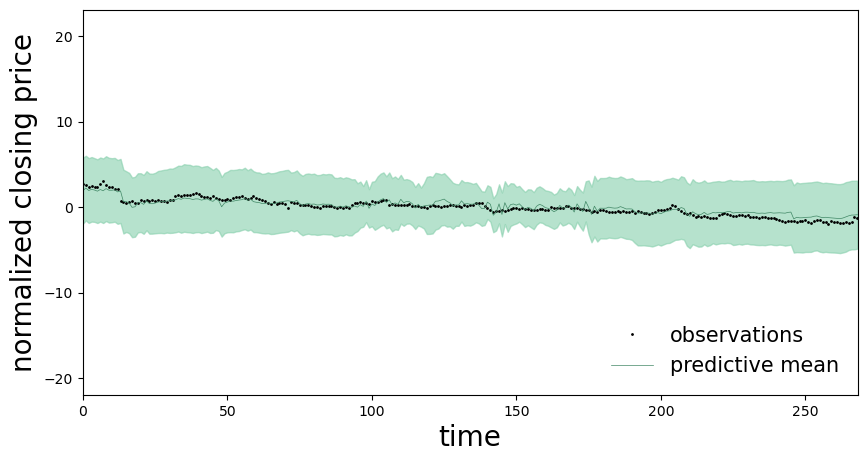

In [17]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

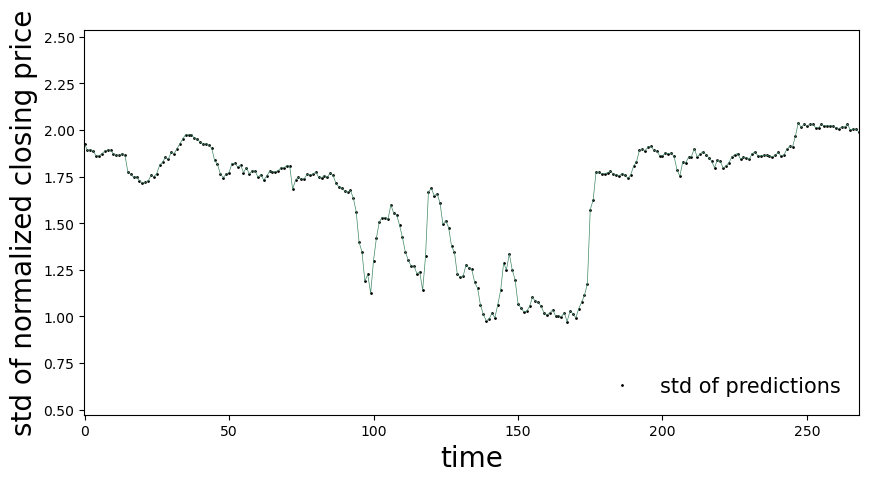

In [18]:
plot_uncertainty(preds, y_pre_n)

### 4. uncertainty quantification of data post GDPR

#### 4.1 Train the prior of BNN.

In [19]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 1000  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 12.0604
>>> Iteration #  10: Wasserstein Dist 2.6908
>>> Iteration #  20: Wasserstein Dist 3.3239
>>> Iteration #  30: Wasserstein Dist 2.7930
>>> Iteration #  40: Wasserstein Dist 1.9225
>>> Iteration #  50: Wasserstein Dist 2.9080
>>> Iteration #  60: Wasserstein Dist 2.0005
>>> Iteration #  70: Wasserstein Dist 2.1645
>>> Iteration #  80: Wasserstein Dist 1.7726
>>> Iteration #  90: Wasserstein Dist -0.1797
>>> Iteration # 100: Wasserstein Dist 2.2865
>>> Iteration # 110: Wasserstein Dist 1.5548
>>> Iteration # 120: Wasserstein Dist 2.0985
>>> Iteration # 130: Wasserstein Dist 2.3151
>>> Iteration # 140: Wasserstein Dist 1.7068
>>> Iteration # 150: Wasserstein Dist 0.4541
>>> Iteration # 160: Wasserstein Dist 0.8670
>>> Iteration # 170: Wasserstein Dist 1.4432
>>> Iteration # 180: Wasserstein Dist 0.8955
>>> Iteration # 190: Wasserstein Dist -1.1787
>>> Iteration # 200: Wasserstein Dist -0.5878
>>> Iteration # 210: Wasserstein Dist 0.9565
>>> It

In [20]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([5.9773], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([5.0343], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1558], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-3.6992], requires_grad=True)


In [21]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(5.9773), maintain_positivity(1.1558)]
post_bias_prior = [maintain_positivity(5.0343), maintain_positivity(-3.6992)]

#### 4.2 train the BNN

In [22]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [23]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 2/10000 [00:00<33:13,  5.02it/s, loss=1495.870]

[iteration 0001] loss: 1593.507


 50%|█████     | 5002/10000 [14:34<13:44,  6.06it/s, loss=29.161]  

[iteration 5001] loss: 24.720


100%|██████████| 10000/10000 [28:39<00:00,  5.81it/s, loss=18.293]


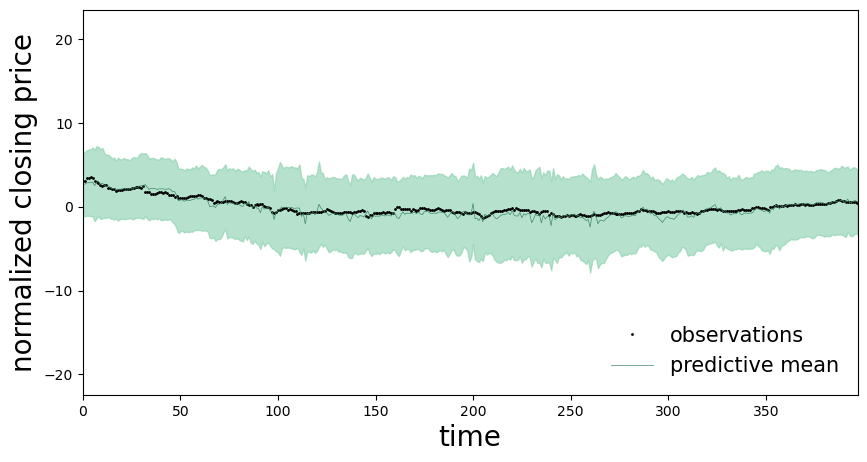

In [24]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

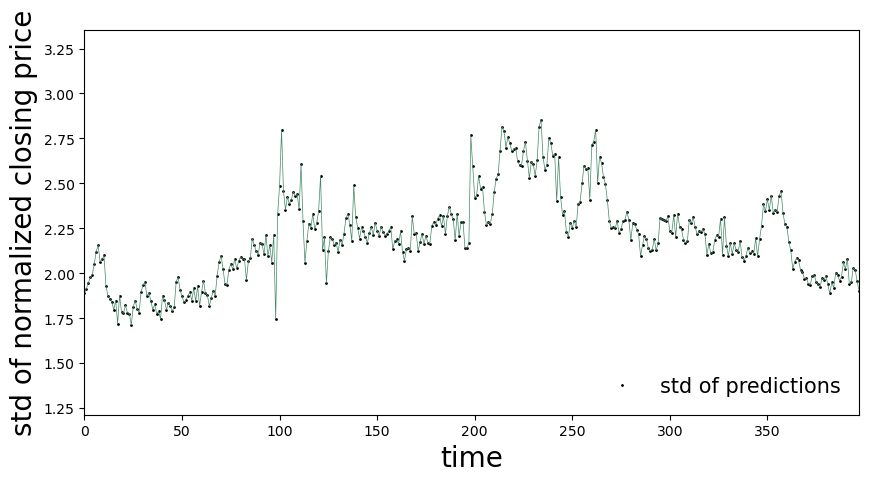

In [25]:
plot_uncertainty(preds, y_post_n)